# Tokenization Study

## Datasets: Loading and Cleaning

### Itihasa

In [273]:
import requests

url = "https://raw.githubusercontent.com/rahular/itihasa/main/data/dev.sn"

data = requests.get(url).text.splitlines()

In [274]:
data[:2]

['तस्यां चीरं वसानायां नाथवत्यामनाथवत्। प्रचुक्रोश जनः सर्वो धिक् त्वां दशरथं त्विति ॥',
 'तेन तत्र प्रणादेन दुःखितः स महीपतिः। चिच्छेद जीविते श्रद्धां धर्मे यशसि चात्मनः॥ स निःश्वस्योष्णमैक्ष्वाकस्तां भार्यामिदमब्रवीत्। कैकेयि कुशचीरेण न सीता गन्तुमर्हति॥']

In [275]:
# searching for Sandhis: This just means that this dataset has sandhis and is not a disolved dataset.

matches = [line for line in data if "ऽ" in line]

print(len(matches))
print(matches[0])

1096
रामेण यदि ते पापे किंचित्कृतमशोभनम्। अपकारः क इह ते वैदेह्या दर्शितोऽधमे॥


#### Data Cleaning

Going through all the unicode letters and determining any anomilities:

In [278]:
import unicodedata

unique_chars = sorted(set("".join(data)))

for ch in unique_chars:
    print(
        repr(ch),
        hex(ord(ch)),
        unicodedata.name(ch, "UNKNOWN")
    )

' ' 0x20 SPACE
'!' 0x21 EXCLAMATION MARK
"'" 0x27 APOSTROPHE
'(' 0x28 LEFT PARENTHESIS
')' 0x29 RIGHT PARENTHESIS
',' 0x2c COMMA
'-' 0x2d HYPHEN-MINUS
'.' 0x2e FULL STOP
':' 0x3a COLON
'?' 0x3f QUESTION MARK
'[' 0x5b LEFT SQUARE BRACKET
'_' 0x5f LOW LINE
'ā' 0x101 LATIN SMALL LETTER A WITH MACRON
'ँ' 0x901 DEVANAGARI SIGN CANDRABINDU
'ं' 0x902 DEVANAGARI SIGN ANUSVARA
'ः' 0x903 DEVANAGARI SIGN VISARGA
'अ' 0x905 DEVANAGARI LETTER A
'आ' 0x906 DEVANAGARI LETTER AA
'इ' 0x907 DEVANAGARI LETTER I
'ई' 0x908 DEVANAGARI LETTER II
'उ' 0x909 DEVANAGARI LETTER U
'ऊ' 0x90a DEVANAGARI LETTER UU
'ऋ' 0x90b DEVANAGARI LETTER VOCALIC R
'ए' 0x90f DEVANAGARI LETTER E
'ऐ' 0x910 DEVANAGARI LETTER AI
'ओ' 0x913 DEVANAGARI LETTER O
'औ' 0x914 DEVANAGARI LETTER AU
'क' 0x915 DEVANAGARI LETTER KA
'ख' 0x916 DEVANAGARI LETTER KHA
'ग' 0x917 DEVANAGARI LETTER GA
'घ' 0x918 DEVANAGARI LETTER GHA
'ङ' 0x919 DEVANAGARI LETTER NGA
'च' 0x91a DEVANAGARI LETTER CA
'छ' 0x91b DEVANAGARI LETTER CHA
'ज' 0x91c DEVANAGARI LETTER JA


I] Punctuation:

Traditional Sanskrit manuscripts generally do not contain modern punctuation marks. Therefore, the following symbols could be removed during preprocessing:

'!' 0x21 EXCLAMATION MARK

'(' 0x28 LEFT PARENTHESIS

')' 0x29 RIGHT PARENTHESIS

',' 0x2c COMMA

'-' 0x2d HYPHEN-MINUS

'?' 0x3f QUESTION MARK

'[' 0x5b LEFT SQUARE BRACKET

'_' 0x5f LOW LINE

'—' 0x2014 EM DASH

'‘' 0x2018 LEFT SINGLE QUOTATION MARK

'”' 0x201d RIGHT DOUBLE QUOTATION MARK

'•' 0x2022 BULLET

However, for training a Sanskrit language model, retaining such punctuation may be beneficial because modern digital Sanskrit texts frequently contain these symbols as they are used in everyday nuances.


II] Non-Standard Sanskrit Characters and OCR Artifacts:

The below charachters are definitely not part of standard sanskrit and OCR errors:

'़' 0x93c DEVANAGARI SIGN NUKTA

'ॅ' 0x945 DEVANAGARI VOWEL SIGN CANDRA E

'॑' 0x951 DEVANAGARI STRESS SIGN UDATTA

'॒' 0x952 DEVANAGARI STRESS SIGN ANUDATTA

'ā' 0x101 LATIN SMALL LETTER A WITH MACRON

"'" 0x27 APOSTROPHE

While nukta and anudatta/ udatta are part of vedic sanskrit, they are not a part of standard sanskrit. Since this study focuses on Classical Sanskrit tokenization, these characters are removed.


III] Manual Inspection of Rare Characters

'क़' 0x958 DEVANAGARI LETTER QA

'ऱ' 0x931 DEVANAGARI LETTER RRA

These letters are primarily associated with Hindi and Urdu orthography. Their occurrences in the corpus were manually inspected. As each character occurred only once and was determined to be an OCR or transcription error, it was replaced with its appropriate Sanskrit counterpart.

IV] Character Normalization

The following normalizations were applied:

'.' (U+002E) FULL STOP → '।' (U+0964) DEVANAGARI DANDA

'ॊ' (U+094A) DEVANAGARI VOWEL SIGN SHORT O → 'ो' (U+094B) DEVANAGARI VOWEL SIGN O

In [280]:
for text in data:
    for word in text.split():
        if "ऱ" in word:
            print(word)

नागलोकमपर्यन्तमनेकाविधप्रासादहऱ्यावलभीनि!हशतसंकुलमुच्चावचक्रीडश्चर्यस्थानावकीर्णमपश्यत्॥


In [282]:
for text in data:
    if "ऱ" in text:
        print(text.replace("ऱ", "[ऱ]"))

तमुत्तोऽनुविवेश तेनैव बिलेन प्रविश्य च तं नागलोकमपर्यन्तमनेकाविधप्रासादह[ऱ]्यावलभीनि!हशतसंकुलमुच्चावचक्रीडश्चर्यस्थानावकीर्णमपश्यत्॥


In [284]:
for text in data:
  if "क़" in text:
    print(text)

सुग्रीवेण तु निःशक़ सालमुत्पाट्य तेजसा। गात्रेष्वभिहतो वाली वज्रेणेव महागिरिः॥


In [ ]:
import re

def clean_text(corpus:list):

    texts = []

    for sentence in corpus:
      sentence = sentence.strip()

      # normalize whitespace
      sentence = re.sub(r"\s+", " ", sentence)
      sentence = re.sub(r"\.", "", sentence)

      # separate danda symbols
      sentence = re.sub(r"॥", " ॥ ", sentence)
      sentence = re.sub(r"।", " । ", sentence)

      # separate danda symbols
      # sentence = re.sub(r"\|\|", " || ", sentence)
      # sentence = re.sub(r"\|", " | ", sentence)

      # cleanup spaces again
      sentence = re.sub(r"\s+", " ", sentence)

      """
      The following are implemented after initial encoding <==> decoding
      comparision
      """

      # cleaning nukta consonants to base consonants
      char_map = {
          "क़": "क",
          "ख़": "ख",
          "ग़": "ग",
          "ज़": "ज",
          "फ़": "फ",
          "ऩ": "न",
          "ऱ": "र"}

      for old, new in char_map.items():
        sentence = sentence.replace(old, new)


      #  cleanup symbols
      sentence = re.sub(r"\s+", " ", sentence)



      texts.append(sentence)

    return texts

In [266]:
for text in data:
    for word in text.split():
        if "ॅ" in word:
            print(word)

किञ्चिदस्मॅिल्लोके
सर्वतःश्रुतिमॅल्लोके


In [267]:
count = 0
for text in data:
    count += text.count("ॅ")

print(count)

2


In [ ]:
data = clean_text(data)
data[:2]

In [216]:
# Corpus Statistics:


def corpus_statistics(data):
  """
  corpus statistics
  """

# Calculate metrics for the dataset
  num_verses = len(data)

# Calculate num_lines by counting ' । ' and ' ॥ ' delimiters
  num_lines = 0
  for sentence in data:
    num_lines += sentence.count(' । ')
    num_lines += sentence.count(' ॥ ')


  total_characters = sum(len(sentence.replace(' ', '')) for sentence in data)
  total_words = sum(len(sentence.split()) for sentence in data)

  print(f"Number of verses: {num_verses}")
  print(f"Number of lines: {num_lines}")
  print(f"Total characters (excluding spaces): {total_characters}")
  print(f"Total words: {total_words}")

  # Calculate averages
  average_words_per_verse = total_words / num_verses
  average_chars_per_verse = total_characters / num_verses
  average_words_per_line = total_words / num_lines
  average_chars_per_line = total_characters / num_lines

  print(f"\n")
  print(f"Average words per verse: {average_words_per_verse:.2f}")
  print(f"Average characters per verse: {average_chars_per_verse:.2f}")
  print(f"Average words per line: {average_words_per_line:.2f}")
  print(f"Average characters per line: {average_chars_per_line:.2f}")

In [217]:
corpus_statistics(data)

Number of verses: 6148
Number of lines: 14487
Total characters (excluding spaces): 549817
Total words: 85680


Average words per verse: 13.94
Average characters per verse: 89.43
Average words per line: 5.91
Average characters per line: 37.95


## Loading the tokenizers

### GPT Tokenizers for old and new

In [ ]:
# they live in the tiktoken environmemt, and here i can use the name as tokenizers using .encode:

import tiktoken
gpt_enc = tiktoken.get_encoding("cl100k_base")
o200k_enc = tiktoken.get_encoding("o200k_base")

### SentencePiece

As used by (Kumar, 2026)

In [ ]:
import requests
!wget https://raw.githubusercontent.com/NikhilaGadge/Sanskrit_Tokenization_Study/main/sentencepiece/spm_sa.model

In [ ]:
import sentencepiece as spm
from pathlib import Path

def load_spm(lang: str) -> spm.SentencePieceProcessor:
    sp = spm.SentencePieceProcessor()
    sp.load("spm_sa.model")
    return sp

In [ ]:
sp_sa = load_spm("sa")

### SansGPT Tokenizer

In [ ]:
!wget https://raw.githubusercontent.com/rhugvedd/SansGPT-Advancing-Generative-Pre-Training-in-Sanskrit/master/BPETokenizer.py
!wget https://raw.githubusercontent.com/NikhilaGadge/Sanskrit_Tokenization_Study/main/SansGPT/Final-Corpus-Tokenizer-Merge-Info-NL-12000-.pkl
!wget https://raw.githubusercontent.com/NikhilaGadge/Sanskrit_Tokenization_Study/main/SansGPT/Final-Corpus-Tokenizer-Vocab-NL-12000-.pkl

In [ ]:
vocab_path = "./"
merge_info_name = "Final-Corpus-Tokenizer-Merge-Info-NL-12000-"
vocab_name = "Final-Corpus-Tokenizer-Vocab-NL-12000-"

In [ ]:
# SansGPT BPE Tokenizer:
# as implemented in paper

from BPETokenizer import BPETokenizer

Tokenizer = BPETokenizer()
Tokenizer.load(vocab_path, merge_info_name, vocab_name)

In [ ]:
dir(Tokenizer)

In [ ]:
class SansGPTTokeinzer:
    """
    Thin adapter that makes BPETokenizer speak the same interface as every
    other tokenizer in the pipeline:

        .encode(sentence)   → flat list of int token IDs
        .tokenize(sentence) → list of token strings
        .decode(token_ids)  → decoded UTF-8 string

    The pipeline's tokenize() function calls these three methods.
    """

    def __init__(self, tok):
        self.tok = tok
        print(type(tok))

        # Metadata for benchmark tables

        self.vocab_size = len(tok.Vocab)
        self.name_or_path = tok.__class__.__name__

        self.backend_model = type(tok).__name__

        try:
          self.special_tokens_map = {
              "special_tokens": tok.special_tokens
              }
        except:
          self.special_tokens_map = {}





        # --- pre-build DecodedBytes lookup once, reuse across all calls ---
        # Rebuilding this per-call (as Decode() does internally) is O(vocab_size)
        # and would be expensive inside a sentence loop.


        self._decoded_bytes = {}
        for i in range(256):
            self._decoded_bytes[i] = bytes([i])
        for (m0, m1), mgd in self.tok.MergeInfo.items():
            self._decoded_bytes[mgd] = self._decoded_bytes[m0] + self._decoded_bytes[m1]

        print(f"[SansGPTTokenizerWrapper] Loaded. Vocab size: {len(self.tok.Vocab)}, "
              f"MergeInfo entries: {len(self.tok.MergeInfo)}")

    # ------------------------------------------------------------------
    # .encode(sentence) → flat list[int]
    # ------------------------------------------------------------------

    def encode(self, sentence: str) -> list:
        """
        EncodeFromText returns a LIST OF LISTS — one inner list per text
        segment produced by the similarity-word splitter in GetCleanedText.
        We flatten into a single list so the pipeline's tokenize() function
        gets a plain sequence of token IDs.
        """
        # WithoutNewLine=True  → joins lines with spaces (correct for inference)
        # SkipFirstChunkInLine=False → do not strip the first word of each line
        # Replacements={}      → no substitutions at inference time
        nested = self.tok.EncodeFromText(
            sentence,
            WithoutNewLine=False,
            SkipFirstChunkInLine=False,
            Replacements={}
        )
        # Flatten list-of-lists → flat list
        flat = [tok_id for segment in nested for tok_id in segment]
        return flat

    # ------------------------------------------------------------------
    # .tokenize(sentence) → list[str]
    # ------------------------------------------------------------------

    def tokenize(self, sentence: str) -> list:
        """
        Returns each token as a human-readable string.
        Uses the pre-built _decoded_bytes lookup so this is O(n_tokens).
        """
        token_ids = self.encode(sentence)
        token_strings = []
        for tid in token_ids:
            raw_bytes = self._decoded_bytes.get(tid, b'')
            token_strings.append(raw_bytes.decode('utf-8', errors='replace'))
        return token_strings

    # ------------------------------------------------------------------
    # .decode(token_ids) → str
    # ------------------------------------------------------------------

    def decode(self, token_ids: list, **kwargs) -> str:
        """
        Reconstructs a UTF-8 string from a flat list of token IDs.

        The pipeline's tokenize() function tries:
            tokenizer.decode(tokens, skip_special_tokens=True)
        and falls back to:
            tokenizer.decode(tokens)
        **kwargs absorbs skip_special_tokens so both call-sites work without error.
        """
        raw = b''.join(
            self._decoded_bytes.get(tid, b'')
            for tid in token_ids
        )
        return raw.decode('utf-8', errors='replace')

In [ ]:
sansgpt = SansGPTTokeinzer(Tokenizer)

In [ ]:
print(sansgpt.backend_model)

In [ ]:
# Paste and run this cell immediately
print("Vocab size:      ", len(sansgpt.tok.Vocab))
print("MergeInfo size:  ", len(sansgpt.tok.MergeInfo))

# Check a few MergeInfo keys
sample = list(sansgpt.tok.MergeInfo.items())[:5]
print("Sample MergeInfo entries:")
for k, v in sample:
    print(f"  {k} → {v}  | key type: {type(k)}, element types: {type(k[0])}, {type(k[1])}")

### Sutra

In [ ]:
from google.colab import userdata
from huggingface_hub import login
from transformers import AutoTokenizer

login(userdata.get("HF_TOKEN"))

In [ ]:
sutra = AutoTokenizer.from_pretrained("TWO/sutra-mlt256-v2")

### HF tokenizers

In [ ]:
from transformers import AutoTokenizer

claude = AutoTokenizer.from_pretrained("Xenova/claude-tokenizer")
tiny = AutoTokenizer.from_pretrained("openaccess-ai-collective/tiny-mistral")
sutra = AutoTokenizer.from_pretrained("TWO/sutra-mlt256-v2")
qwen_sanskrit_model = AutoTokenizer.from_pretrained("diabolic6045/Sanskrit-Qwen2.5-7B-base")
qwen_sanskrit_tokenizer = AutoTokenizer.from_pretrained("diabolic6045/Sanskrit-English-qwen2-tokenizer")
mt5 = AutoTokenizer.from_pretrained("google/mt5-small")
mbart = AutoTokenizer.from_pretrained("facebook/mbart-large-50")
airavata = AutoTokenizer.from_pretrained("ai4bharat/Airavata") # needs login
llama = AutoTokenizer.from_pretrained("meta-llama/Llama-3.1-8B-Instruct") # needs login # access granted
aya = AutoTokenizer.from_pretrained("CohereLabs/aya-expanse-8b") # needs login
gemma = AutoTokenizer.from_pretrained("google/gemma-1.1-2b-it") # needs login

## Metadata Tokenizers

In [178]:
import pandas as pd


def tokenizer_metadata_table(tokenizers_dict):

    rows = []

    for label, tok in tokenizers_dict.items():

        row = {
            "label": label,
            "class": getattr(tok, "backend_model", type(tok).__name__),
        }

        # -----------------------------
        # vocab size
        # -----------------------------

        if hasattr(tok, "vocab_size"):
          vocab = tok.vocab_size

          if callable(vocab):
            row["vocab_size"] = vocab()
          else:
            row["vocab_size"] = vocab

        elif hasattr(tok, "n_vocab"):

          row["vocab_size"] = tok.n_vocab

        else:

          row["vocab_size"] = "not available"

        # -----------------------------
        # model path / tokenizer name
        # -----------------------------
        if hasattr(tok, "name_or_path"):

            row["model_path"] = tok.name_or_path

        elif hasattr(tok, "name"):

            row["model_path"] = tok.name

        else:

            row["model_path"] = "not available"


        # -----------------------------
        # backend tokenizer model
        # -----------------------------
        try:

            row["backend_model"] = str(tok.backend_tokenizer.model)

        except:
          if hasattr(tok, "backend_model"):
            row["backend_model"] = tok.backend_model

          else:
            row["backend_model"] = tok.__class__.__name__


        # -----------------------------
        # special tokens
        # -----------------------------
        try:

            row["special_tokens"] = tok.special_tokens_map

        except:

            try:

                row["special_tokens"] = tok._special_tokens

            except:

                row["special_tokens"] = "not available"

        # -----------------------------
        # sentencepiece model
        # -----------------------------

        if type(tok).__name__ == "SentencePieceProcessor":
          row["model_path"] = getattr(tok, "_model_file", "SentencePiece Model")
          row["backend_model"] = type(tok).__name__

          try:
            row["special_tokens"] = {
                "unk_id": tok.unk_id(),
                "bos_id": tok.bos_id(),
                "eos_id": tok.eos_id(),
                "pad_id": tok.pad_id()
                }
          except:
            row["special_tokens"] = "not available"

        rows.append(row)

    meta_df = pd.DataFrame(rows)

    return meta_df

In [179]:
tokenizers = {

    "claude": claude,
    "tiny_mistral": tiny,
    "sutra": sutra,
    "qwen_sanskrit_model": qwen_sanskrit_model,
    "qwen_sanskrit_tokenizer": qwen_sanskrit_tokenizer,
    "mt5": mt5,
    "mbart": mbart,
    "airavata" : airavata, # needs login
    "llama": llama, # needs login # access granted
    "aya": aya, # needs login
    "gemma": gemma, # needs login
    "cl100k_base": gpt_enc,
    "o200k_base": o200k_enc,
    "sentencepiece_sa": sp_sa,
    "sansgpt_tokenizer": sansgpt
}

meta_df = tokenizer_metadata_table(tokenizers)

meta_df

,label,class,vocab_size,model_path,backend_model,special_tokens
0,claude,GPT2Tokenizer,65000,Xenova/claude-tokenizer,"BPE(dropout=None, unk_token=None, continuing_s...","{'bos_token': '<EOT>', 'eos_token': '<EOT>', '..."
1,tiny_mistral,TokenizersBackend,32000,openaccess-ai-collective/tiny-mistral,"BPE(dropout=None, unk_token=""<unk>"", continuin...","{'bos_token': '<s>', 'eos_token': '</s>', 'unk..."
2,sutra,TokenizersBackend,256001,TWO/sutra-mlt256-v2,"BPE(dropout=None, unk_token=""<unk>"", continuin...","{'bos_token': '<s>', 'eos_token': '</s>', 'unk..."
3,qwen_sanskrit_model,Qwen2Tokenizer,151643,diabolic6045/Sanskrit-Qwen2.5-7B-base,"BPE(dropout=None, unk_token=None, continuing_s...","{'eos_token': '<|endoftext|>', 'pad_token': '<..."
4,qwen_sanskrit_tokenizer,TokenizersBackend,120000,diabolic6045/Sanskrit-English-qwen2-tokenizer,"BPE(dropout=None, unk_token=None, continuing_s...","{'eos_token': '<|im_end|>', 'unk_token': '<unk..."
5,mt5,T5Tokenizer,250100,google/mt5-small,"Unigram(unk_id=2, vocab=[(""<pad>"", 0), (""</s>""...","{'eos_token': '</s>', 'unk_token': '<unk>', 'p..."
6,mbart,MBart50Tokenizer,250054,facebook/mbart-large-50,"Unigram(unk_id=3, vocab=[(""<s>"", 0), (""<pad>"",...","{'bos_token': '<s>', 'eos_token': '</s>', 'unk..."
7,airavata,TokenizersBackend,48064,ai4bharat/Airavata,"BPE(dropout=None, unk_token=""<unk>"", continuin...","{'bos_token': '<s>', 'eos_token': '</s>', 'unk..."
8,llama,TokenizersBackend,128000,meta-llama/Llama-3.1-8B-Instruct,"BPE(dropout=None, unk_token=None, continuing_s...","{'bos_token': '<|begin_of_text|>', 'eos_token'..."
9,aya,CohereTokenizer,255000,CohereLabs/aya-expanse-8b,"BPE(dropout=None, unk_token=None, continuing_s...","{'bos_token': '<BOS_TOKEN>', 'eos_token': '<|E..."


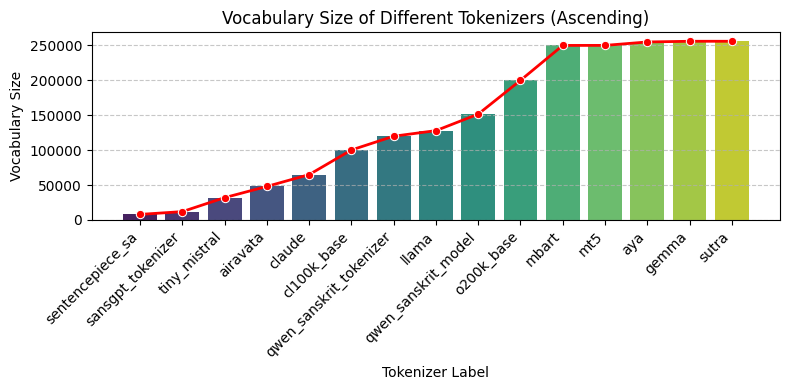

In [180]:
import matplotlib.pyplot as plt
import seaborn as sns

# Sort meta_df by vocab_size in ascending order
sorted_meta_df = meta_df.sort_values(by='vocab_size', ascending=True)

plt.figure(figsize=(8, 4))
sns.barplot(x='label', y='vocab_size', data=sorted_meta_df, palette='viridis', hue='label', legend=False, order=sorted_meta_df['label'])
# Add a rising red line
sns.lineplot(x='label', y='vocab_size', data=sorted_meta_df, color='red', marker='o', linewidth=2, sort=False)
plt.title('Vocabulary Size of Different Tokenizers (Ascending)')
plt.xlabel('Tokenizer Label')
plt.ylabel('Vocabulary Size')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

## Evaluation

In [218]:
import pandas as pd
import numpy as np
from google.colab import files
import contextlib
import io
from tqdm.auto import tqdm

def tokenize(data: list, tokenizer, tokenizer_label):
    """
    Tokenizes each sentence individually.
    Returns a DataFrame — one row per sentence.
    """

    records = []

    for sentence in tqdm(data, desc=tokenizer_label):

        if not sentence.strip():
            continue

        # -----------------------------
        # SansGPT
        # -----------------------------

        if type(tokenizer).__name__ == "BPETokenizer":

            with contextlib.redirect_stdout(io.StringIO()):

                tokens = tokenizer.EncodeFromText(
                    sentence,
                    WithoutNewLine=False,
                    SkipFirstChunkInLine=False,
                    Replacements={}
                )

            token_strings = [
                tokenizer.Decode(chunk)
                for chunk in tokens
            ]

            num_tokens = len(tokens)

            decoded = "".join(token_strings)

        # -----------------------------
        # All other tokenizers
        # -----------------------------

        else:

            tokens = tokenizer.encode(sentence)

            try:
                token_strings = tokenizer.tokenize(sentence)

            except:
                token_strings = [
                    tokenizer.decode([t])
                    for t in tokens
                ]

            num_tokens = len(tokens)

            try:
                decoded = tokenizer.decode(
                    tokens,
                    skip_special_tokens=True
                )

            except:
                decoded = tokenizer.decode(tokens)

        # -----------------------------
        # Common calculations
        # -----------------------------

        words = sentence.split()

        num_words = len(words)

        num_chars = len(
            sentence.replace(" ", "")
        )

        records.append({

            "sentence": sentence,
            "decoded_sentence": decoded,
            "tokens": token_strings,
            "similarity": sentence.strip() == decoded.strip(),
            "num_words": num_words,
            "num_tokens": num_tokens,
            # "unique_tokens_count": len(set(tokens)),
            "token_ids": tokens,
            "num_chars": num_chars,
            "fertility": num_tokens / num_words if num_words > 0 else None,
            "tokens_per_char": num_tokens / num_chars if num_chars > 0 else None,
            "chars_per_token": num_chars / num_tokens if num_tokens > 0 else None,
            "tokenizer": tokenizer_label
        })

    df = pd.DataFrame(records)

    return df

## Tokenizer wise results:

In [219]:
# gpt_enc = tiktoken.get_encoding("cl100k_base")
tokenize(data, gpt_enc, "cl100k_base").head(2)

cl100k_base:   0%|          | 0/6148 [00:00<?, ?it/s]

,sentence,decoded_sentence,tokens,similarity,num_words,num_tokens,token_ids,num_chars,fertility,tokens_per_char,chars_per_token,tokenizer
0,तस्यां चीरं वसानायां नाथवत्यामनाथवत् । प्रचुक्...,तस्यां चीरं वसानायां नाथवत्यामनाथवत् । प्रचुक्...,"[त, स, ्�, �, ा�, �, �, �, ी, र, ं, �, �, स,...",True,13,91,"[80338, 79468, 31584, 107, 32511, 224, 15272, ...",73,7.000000,1.246575,0.802198,cl100k_base
1,तेन तत्र प्रणादेन दुःखितः स महीपतिः । चिच्छेद ...,तेन तत्र प्रणादेन दुःखितः स महीपतिः । चिच्छेद ...,"[त, े�, �, �, �, त, ्र, प, ्र, �, �, ा�, �, ...",True,24,179,"[80338, 55884, 101, 15272, 97, 80338, 86133, 8...",146,7.458333,1.226027,0.815642,cl100k_base


In [221]:
verse = data[:100]
tokenize(verse, Tokenizer,"sansgpt")

sansgpt:   0%|          | 0/100 [00:00<?, ?it/s]

,sentence,decoded_sentence,tokens,similarity,num_words,num_tokens,token_ids,num_chars,fertility,tokens_per_char,chars_per_token,tokenizer
0,तस्यां चीरं वसानायां नाथवत्यामनाथवत् । प्रचुक्...,तस्यां चीरं वसानायां नाथवत्यामनाथवत् । प्रचुक्...,"[तस, ्य, ां, च, ीर, ं, वस, ान, ाय, ां, न, ा...",True,13,41,"[[224, 164, 164, 224, 164, 184], [268, 141, 22...",73,3.153846,0.561644,1.780488,sansgpt
1,तेन तत्र प्रणादेन दुःखितः स महीपतिः । चिच्छेद ...,तेन तत्र प्रणादेन दुःखितः स महीपतिः । चिच्छेद ...,"[त, ेन, तत, ्र, प, ्रण, ाद, ेन, द, ुः, ख, ि...",True,24,82,"[[224, 164, 164], [268, 135, 224, 164, 168], [...",146,3.416667,0.561644,1.780488,sansgpt
2,सुकुमारी च बाला च सततं च सुखोचिता । नेयं वनस्य...,सुकुमारी च बाला च सततं च सुखोचिता । नेयं वनस्य...,"[स, ुक, ुम, ार, ी, च, ब, ाल, ा, च, सतत, ं,...",True,14,38,"[[224, 164, 184], [268, 129, 224, 164, 149], [...",61,2.714286,0.622951,1.605263,sansgpt
3,इयं हि कस्यापि करोति किंचित् तपस्विनी राजवरस्य...,इयं हि कस्यापि करोति किंचित् तपस्विनी राजवरस्य...,"[इय, ं, ह, ि, कस, ्य, ाप, ि, कर, ोत, ि, क,...",True,18,57,"[[224, 164, 135, 224, 164, 175], [224, 164, 13...",95,3.166667,0.600000,1.666667,sansgpt
4,चीराण्यपास्याज्जनकस्य कन्या नेयं प्रतिज्ञा मम ...,चीराण्यपास्याज्जनकस्य कन्या नेयं प्रतिज्ञा मम ...,"[च, ीर, ाण, ्यप, ास, ्य, ाज, ्जनकस, ्य, कन, ्...",True,15,51,"[[224, 164, 154], [268, 128, 224, 164, 176], [...",96,3.400000,0.531250,1.882353,sansgpt
...,...,...,...,...,...,...,...,...,...,...,...,...
95,शोकेन महता त्रस्ता मैथिली जनकात्मजा । न शर्म ल...,शोकेन महता त्रस्ता मैथिली जनकात्मजा । न शर्म ल...,"[श, ोक, ेन, महत, ा, त, ्रस, ्त, ा, म, ैथ, ि...",True,14,37,"[[224, 164, 182], [268, 139, 224, 164, 149], [...",62,2.642857,0.596774,1.675676,sansgpt
96,न विन्दते तत्र तु शर्म मैथिली विरूपनेत्राभिरती...,न विन्दते तत्र तु शर्म मैथिली विरूपनेत्राभिरती...,"[न, व, िन, ्दत, े, तत, ्र, त, ु, शर, ्म, ...",True,17,54,"[[224, 164, 168], [32, 224, 164, 181], [224, 1...",95,3.176471,0.568421,1.759259,sansgpt
97,इतः परं प्रक्षिप्तोऽयं सर्गः । । प्रवेशितायां ...,इतः परं प्रक्षिप्तोऽयं सर्गः । । प्रवेशितायां ...,"[इत, ः, पर, ं, प, ्रक, ्ष, िप, ्त, ोऽय, ं, ...",True,18,58,"[[224, 164, 135, 224, 164, 164], [224, 164, 13...",102,3.222222,0.568627,1.758621,sansgpt
98,त्रैलोक्यस्य हितार्थाय रक्षसामहिताय च । लङ्कां...,त्रैलोक्यस्य हितार्थाय रक्षसामहिताय च । लङ्कां...,"[त, ्र, ैल, ोक, ्यस, ्य, ह, ित, ार, ्थ, ाय, ...",True,11,39,"[[224, 164, 164], [268, 141, 224, 164, 176], [...",70,3.545455,0.557143,1.794872,sansgpt


In [215]:
tokenize(data, Tokenizer,"sansgpt")

KeyboardInterrupt: 

In [222]:
df = tokenize(data[:100], Tokenizer, "sansgpt")

print(df["num_tokens"].describe())

sansgpt:   0%|          | 0/100 [00:00<?, ?it/s]

count    100.000000
mean      50.080000
std       19.626657
min       31.000000
25%       39.000000
50%       42.000000
75%       53.250000
max      140.000000
Name: num_tokens, dtype: float64


In [223]:
tokenizer_names = []

tokenizers = [

    ("claude", claude),
    ("tiny", tiny),
    ("sutra", sutra),
    ("qwen_sanskrit_model", qwen_sanskrit_model),
    ("qwen_sanskrit_tokenizer", qwen_sanskrit_tokenizer),
    ("mt5", mt5),
    ("mbart", mbart),
    ("airavata" , airavata), # needs login
    ("llama", llama), # needs login # access granted
    ("aya", aya), # needs login
    ("gemma", gemma), # needs login
    ("cl100k_base", gpt_enc),
    ("o200k_base", o200k_enc),
    ("sentencepiece_sa", sp_sa),
    ("sansgpt", Tokenizer)

]

for tok, name in tokenizers:
  print(f"Running {name}")
  temp_df = tokenize(data, name, tok)
  tokenizer_names.append(temp_df)

df = pd.concat(tokenizer_names, ignore_index = True)

Running GPT2Tokenizer(name_or_path='Xenova/claude-tokenizer', vocab_size=65000, model_max_length=200000, padding_side='right', truncation_side='right', special_tokens={'bos_token': '<EOT>', 'eos_token': '<EOT>', 'unk_token': '<EOT>'}, added_tokens_decoder={
	0: AddedToken("<EOT>", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	1: AddedToken("<META>", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	2: AddedToken("<META_START>", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	3: AddedToken("<META_END>", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	4: AddedToken("<SOS>", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
}
)


claude:   0%|          | 0/6148 [00:00<?, ?it/s]

Running TokenizersBackend(name_or_path='openaccess-ai-collective/tiny-mistral', vocab_size=32000, model_max_length=1000000000000000019884624838656, padding_side='right', truncation_side='right', special_tokens={'bos_token': '<s>', 'eos_token': '</s>', 'unk_token': '<unk>'}, added_tokens_decoder={
	0: AddedToken("<unk>", rstrip=False, lstrip=False, single_word=False, normalized=True, special=True),
	1: AddedToken("<s>", rstrip=False, lstrip=False, single_word=False, normalized=True, special=True),
	2: AddedToken("</s>", rstrip=False, lstrip=False, single_word=False, normalized=True, special=True),
}
)


tiny:   0%|          | 0/6148 [00:00<?, ?it/s]

Running TokenizersBackend(name_or_path='TWO/sutra-mlt256-v2', vocab_size=256001, model_max_length=1000000000000000019884624838656, padding_side='right', truncation_side='right', special_tokens={'bos_token': '<s>', 'eos_token': '</s>', 'unk_token': '<unk>', 'sep_token': '</s>', 'pad_token': '<pad>', 'cls_token': '<s>', 'mask_token': '<mask>'}, added_tokens_decoder={
	0: AddedToken("<s>", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	1: AddedToken("<pad>", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	2: AddedToken("</s>", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	3: AddedToken("<unk>", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	256001: AddedToken("hin_Deva", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	256002: AddedToken("ben_Beng", rstrip=False, lstrip=False, single_word=False, normalized=False, special=Tr

...

o200k_base:   0%|          | 0/6148 [00:00<?, ?it/s]

Running <sentencepiece.SentencePieceProcessor; proxy of <Swig Object of type 'sentencepiece::SentencePieceProcessor *' at 0x7a56ed998930> >


sentencepiece_sa:   0%|          | 0/6148 [00:00<?, ?it/s]

Running <BPETokenizer.BPETokenizer object at 0x7a578c2f78c0>


sansgpt:   0%|          | 0/6148 [00:00<?, ?it/s]

In [224]:
# uncomment to download a file


filename = f"tokenizer_analysis.xlsx"

df.to_excel(filename, index=False)

files.download(filename)



<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [225]:
df['tokenizer'].unique()

array(['claude', 'tiny', 'sutra', 'qwen_sanskrit_model',
       'qwen_sanskrit_tokenizer', 'mt5', 'mbart', 'airavata', 'llama',
       'aya', 'gemma', 'cl100k_base', 'o200k_base', 'sentencepiece_sa',
       'sansgpt'], dtype=object)

In [226]:
df.head(2)

,sentence,decoded_sentence,tokens,similarity,num_words,num_tokens,token_ids,num_chars,fertility,tokens_per_char,chars_per_token,tokenizer
0,तस्यां चीरं वसानायां नाथवत्यामनाथवत् । प्रचुक्...,तस्यां चीरं वसानायां नाथवत्यामनाथवत् । प्रचुक्...,"[à¤¤, à¤¸, à¥į, à¤, ¯, à¤¾, à¤Ĥ, Ġà¤, ļ, à¥Ģ, ...",True,13,103,"[45793, 56377, 38639, 5333, 112, 24332, 40786,...",73,7.923077,1.410959,0.708738,claude
1,तेन तत्र प्रणादेन दुःखितः स महीपतिः । चिच्छेद ...,तेन तत्र प्रणादेन दुःखितः स महीपतिः । चिच्छेद ...,"[à¤¤, à¥ĩ, à¤¨, Ġà¤, ¤, à¤¤, à¥į, à¤°, Ġà¤, ª,...",True,24,203,"[45793, 29050, 37134, 13348, 102, 45793, 38639...",146,8.458333,1.390411,0.719212,claude


In [227]:
df.tail(2)

,sentence,decoded_sentence,tokens,similarity,num_words,num_tokens,token_ids,num_chars,fertility,tokens_per_char,chars_per_token,tokenizer
92218,योनिस्त्वमस्य प्रलयश्च कृष्ण त्वमेवेदं सृजसे व...,योनिस्त्वमस्य प्रलयश्च कृष्ण त्वमेवेदं सृजसे व...,"[य, ोन, िस, ्त, ्वमस, ्य, प, ्रलयश, ्च, क, ृ...",True,15,57,"[[224, 164, 175], [268, 139, 224, 164, 168], [...",103,3.800000,0.553398,1.807018,sansgpt
92219,एवं स्तुतो धर्मराजेन कृष्णः सभामध्ये प्रीतिमान...,एवं स्तुतो धर्मराजेन कृष्णः सभामध्ये प्रीतिमान...,"[एव, ं, स, ्त, ुत, ो, धर, ्मर, ाज, ेन, क, ृ...",True,15,64,"[[224, 164, 143, 224, 164, 181], [224, 164, 13...",114,4.266667,0.561404,1.781250,sansgpt


In [228]:
df[df['sentence'] == "तस्यां चीरं वसानायां नाथवत्यामनाथवत् । प्रचुक्रोश जनः सर्वो धिक् त्वां दशरथं त्विति ॥ "]

,sentence,decoded_sentence,tokens,similarity,num_words,num_tokens,token_ids,num_chars,fertility,tokens_per_char,chars_per_token,tokenizer
0,तस्यां चीरं वसानायां नाथवत्यामनाथवत् । प्रचुक्...,तस्यां चीरं वसानायां नाथवत्यामनाथवत् । प्रचुक्...,"[à¤¤, à¤¸, à¥į, à¤, ¯, à¤¾, à¤Ĥ, Ġà¤, ļ, à¥Ģ, ...",True,13,103,"[45793, 56377, 38639, 5333, 112, 24332, 40786,...",73,7.923077,1.410959,0.708738,claude
6148,तस्यां चीरं वसानायां नाथवत्यामनाथवत् । प्रचुक्...,तस्यां चीरं वसानायां नाथवत्यामनाथवत् । प्रचुक्...,"[▁, त, स, ्, य, ा, ं, ▁, च, ी, र, ं, ▁, व, स, ...",True,13,92,"[1, 28705, 29708, 29671, 29300, 29896, 29232, ...",73,7.076923,1.260274,0.793478,tiny
12296,तस्यां चीरं वसानायां नाथवत्यामनाथवत् । प्रचुक्...,तस्यां चीरं वसानायां नाथवत्यामनाथवत् । प्रचुक्...,"[▁त, स, ्यां, ▁ची, र, ं, ▁वसा, ना, य, ां, ▁ना,...",False,13,44,"[256012, 7982, 772, 36483, 28974, 765, 724, 16...",73,3.384615,0.602740,1.659091,sutra
18444,तस्यां चीरं वसानायां नाथवत्यामनाथवत् । प्रचुक्...,तस्यां चीरं वसानायां नाथवत्यामनाथवत् । प्रचुक्...,"[à¤¤, à¤¸, à¥įà¤, ¯, à¤¾à¤, Ĥ, Ġà¤, ļ, à¥Ģ, à¤...",True,13,83,"[79238, 78368, 30484, 107, 31411, 224, 14925, ...",73,6.384615,1.136986,0.879518,qwen_sanskrit_model
24592,तस्यां चीरं वसानायां नाथवत्यामनाथवत् । प्रचुक्...,तस्यां चीरं वसानायां नाथवत्यामनाथवत् । प्रचुक्...,"[▁तस्यां, ▁ची, रं, ▁वस, ान, ायां, ▁नाथ, वत्या,...",True,13,21,"[6347, 23964, 645, 2778, 245, 1616, 6661, 1747...",73,1.615385,0.287671,3.476190,qwen_sanskrit_tokenizer
30740,तस्यां चीरं वसानायां नाथवत्यामनाथवत् । प्रचुक्...,तस्यां चीरं वसानायां नाथवत्यामनाथवत् । प्रचुक्...,"[▁, तस्, यां, ▁, ची, रं, ▁, वसा, ना, यां, ▁, न...",True,13,45,"[259, 92038, 108720, 259, 8040, 111093, 259, 1...",73,3.461538,0.616438,1.622222,mt5
36888,तस्यां चीरं वसानायां नाथवत्यामनाथवत् । प्रचुक्...,तस्यां चीरं वसानायां नाथवत्यामनाथवत् । प्रचुक्...,"[▁तस्य, ां, ▁, ची, रं, ▁, वस, ाना, यां, ▁, नाथ...",True,13,41,"[250004, 57123, 11274, 6, 3673, 53405, 6, 7747...",73,3.153846,0.561644,1.780488,mbart
43036,तस्यां चीरं वसानायां नाथवत्यामनाथवत् । प्रचुक्...,तस्यां चीरं वसानायां नाथवत्यामनाथवत् । प्रचुक्...,"[▁, त, स्, यां, ▁, ची, र, ं, ▁व, सा, ना, यां, ...",True,13,51,"[1, 29871, 30475, 32513, 34124, 29871, 33447, ...",73,3.923077,0.698630,1.431373,airavata
49184,तस्यां चीरं वसानायां नाथवत्यामनाथवत् । प्रचुक्...,तस्यां चीरं वसानायां नाथवत्यामनाथवत् । प्रचुक्...,"[à¤¤, à¤¸, à¥įà¤¯, à¤¾à¤Ĥ, Ġà¤ļ, à¥Ģà¤°, à¤Ĥ, ...",True,13,49,"[128000, 80338, 79468, 100305, 100515, 100443,...",73,3.769231,0.671233,1.489796,llama
55332,तस्यां चीरं वसानायां नाथवत्यामनाथवत् । प्रचुक्...,तस्यां चीरं वसानायां नाथवत्यामनाथवत् । प्रचुक्...,"[à¤¤, à¤¸, à¥į, à¤¯, à¤¾à¤Ĥ, Ġà¤ļ, à¥Ģ, à¤°, à...",True,13,64,"[5, 2560, 2960, 2173, 2857, 10451, 10116, 2491...",73,4.923077,0.876712,1.140625,aya


### Encoding and Decoding Similarity:

In [229]:
df['similarity'].value_counts()

,count
similarity,
True,79982
False,12238


In [230]:
df[df['similarity'] == False][['similarity','tokenizer']].drop_duplicates()

,similarity,tokenizer
1475,False,claude
12296,False,sutra
24617,False,qwen_sanskrit_tokenizer
50659,False,llama
79924,False,sentencepiece_sa


## Summary of Metrices

In [231]:
summary = (
    df
    .groupby("tokenizer")
    .agg({
        "num_words": "mean",
        "num_tokens": "mean",
        "fertility": "mean",
        "tokens_per_char": "mean",
        "chars_per_token": "mean"
    })
    .sort_values("fertility", ascending=True)
)
summary_round = round(summary, 1)
summary_round

,num_words,num_tokens,fertility,tokens_per_char,chars_per_token
tokenizer,,,,,
qwen_sanskrit_tokenizer,13.9,21.8,1.6,0.2,4.1
sentencepiece_sa,13.9,37.9,2.8,0.4,2.4
mbart,13.9,41.5,3.1,0.5,2.2
mt5,13.9,48.5,3.6,0.5,1.8
sansgpt,13.9,49.5,3.6,0.6,1.8
o200k_base,13.9,49.6,3.7,0.6,1.8
sutra,13.9,50.3,3.7,0.6,1.8
gemma,13.9,53.6,3.9,0.6,1.7
airavata,13.9,60.7,4.5,0.7,1.5


/tmp/ipykernel_1474/3856549932.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


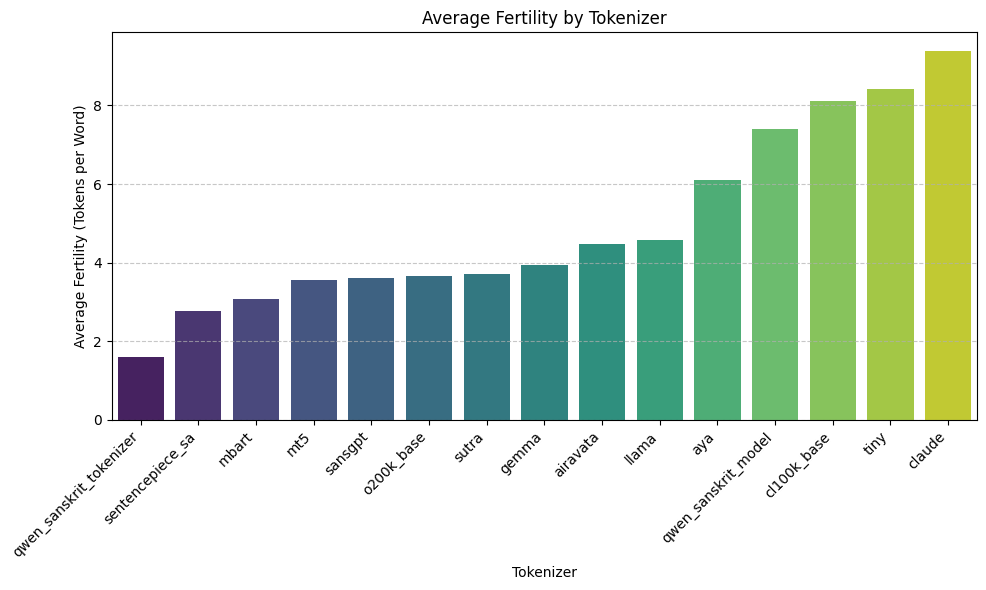

In [232]:
import matplotlib.pyplot as plt
import seaborn as sns

# Calculate average fertility per tokenizer
fertility_summary = (
    df.groupby('tokenizer')['fertility']
      .mean()
      .reset_index()
      .sort_values('fertility', ascending=True)
)

plt.figure(figsize=(10, 6))
sns.barplot(
    x='tokenizer',
    y='fertility',
    data=fertility_summary,
    palette='viridis'
)

plt.title('Average Fertility by Tokenizer')
plt.xlabel('Tokenizer')
plt.ylabel('Average Fertility (Tokens per Word)')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# Vedic Corpus

In [ ]:
!pip install datasets

In [247]:
from datasets import load_dataset
vedic = load_dataset("shunyasea/vedic-sanskrit")

In [248]:
print(vedic)

DatasetDict({
    train: Dataset({
        features: ['text'],
        num_rows: 536641
    })
    test: Dataset({
        features: ['text'],
        num_rows: 59627
    })
})


In [249]:
vedic = vedic["test"]["text"]

In [250]:
vedic[:5]

['वित्रेसुः सर्वभूतानि कषयं पराप्तं च मेनिरे',
 'परिष्ठिता अत्र्णद बद्बधानाः सीरा इन्द्रः सरवितवे पर्थिव्या|',
 'सयावानं धनेधने वाजयन्तम अवा रथम|',
 'त्वं च सङ्कर्षणो देवस्त्वं कर्ता त्वं सनातनः ।',
 'जितेन्द्रियश च वसुधां पराप्स्यसीति च माब्रवीत']

In [251]:
print(len(vedic))

59627


In [252]:
# size of dataset, one wants to set
import random

random.seed(42)
n = 5000
vedic = random.sample(vedic, n)

print(len(vedic))

5000


In [253]:
vedic = clean_text(vedic)

In [254]:
corpus_statistics(vedic)

Number of verses: 5000
Number of lines: 1274
Total characters (excluding spaces): 174175
Total words: 28809


Average words per verse: 5.76
Average characters per verse: 34.84
Average words per line: 22.61
Average characters per line: 136.72


In [255]:
tokenizer_names = []

tokenizers = [

    ("claude", claude),
    ("tiny", tiny),
    ("sutra", sutra),
    ("qwen_sanskrit_model", qwen_sanskrit_model),
    ("qwen_sanskrit_tokenizer", qwen_sanskrit_tokenizer),
    ("mt5", mt5),
    ("mbart", mbart),
    ("airavata" , airavata), # needs login
    ("llama", llama), # needs login # access granted
    ("aya", aya), # needs login
    ("gemma", gemma), # needs login
    ("cl100k_base", gpt_enc),
    ("o200k_base", o200k_enc),
    ("sentencepiece_sa", sp_sa),
    ("sansgpt", Tokenizer)



]

for tok, name in tokenizers:
  temp_df = tokenize(vedic, name, tok)
  tokenizer_names.append(temp_df)

df = pd.concat(tokenizer_names, ignore_index = True)

claude:   0%|          | 0/5000 [00:00<?, ?it/s]

tiny:   0%|          | 0/5000 [00:00<?, ?it/s]

sutra:   0%|          | 0/5000 [00:00<?, ?it/s]

qwen_sanskrit_model:   0%|          | 0/5000 [00:00<?, ?it/s]

qwen_sanskrit_tokenizer:   0%|          | 0/5000 [00:00<?, ?it/s]

...

gemma:   0%|          | 0/5000 [00:00<?, ?it/s]

cl100k_base:   0%|          | 0/5000 [00:00<?, ?it/s]

o200k_base:   0%|          | 0/5000 [00:00<?, ?it/s]

sentencepiece_sa:   0%|          | 0/5000 [00:00<?, ?it/s]

sansgpt:   0%|          | 0/5000 [00:00<?, ?it/s]

In [258]:
df.tail()

,sentence,decoded_sentence,tokens,similarity,num_words,num_tokens,token_ids,num_chars,fertility,tokens_per_char,chars_per_token,tokenizer
72715,सेवेतोष्णं घृतादींश्च पीत्वा शीतं निषेवते ॥,सेवेतोष्णं घृतादींश्च पीत्वा शीतं निषेवते ॥,"[स, ेव, ेत, ोष, ्ण, ं, घ, ृत, ाद, ीं, श, ्च, ...",True,6,25,"[[224, 164, 184], [268, 135, 224, 164, 181], [...",38,4.166667,0.657895,1.520000,sansgpt
72716,यो भवत्यव्ययो व्यापी स वीक्ष्यते मयाद्य ह ॥,यो भवत्यव्ययो व्यापी स वीक्ष्यते मयाद्य ह ॥,"[य, ो, भवत, ्यव, ्यय, ो, व, ्य, ाप, ी, स, ...",True,8,22,"[[224, 164, 175], [268, 139], [32, 224, 164, 1...",36,2.750000,0.611111,1.636364,sansgpt
72717,हिरण्यवर्णो भगवान् उषित्वा परिवत्सरम् ॥,हिरण्यवर्णो भगवान् उषित्वा परिवत्सरम् ॥,"[ह, िरण, ्यवर, ्ण, ो, भगव, ान, ्, उष, ित, ्व...",True,5,18,"[[224, 164, 185], [224, 164, 191, 224, 164, 17...",35,3.600000,0.514286,1.944444,sansgpt
72718,हिरण्ययात परि योनेर्निषद्या हिरण्यदा ददत्यन्नम...,हिरण्ययात परि योनेर्निषद्या हिरण्यदा ददत्यन्नम...,"[ह, िरण, ्यय, ात, पर, ि, य, ोन, ेर, ्न, िषद,...",True,5,22,"[[224, 164, 185], [224, 164, 191, 224, 164, 17...",47,4.400000,0.468085,2.136364,sansgpt
72719,चक्रुर उच्चावचं कर्म यशसॊ ऽरथाय दुष्करम,चक्रुर उच्चावचं कर्म यशसॊ ऽरथाय दुष्करम,"[चक, ्र, ुर, उच, ्च, ावच, ं, कर, ्म, यशस, ॊ...",True,6,16,"[[224, 164, 154, 224, 164, 149], [268, 141, 22...",34,2.666667,0.470588,2.125000,sansgpt


In [256]:
summary = (
    df
    .groupby("tokenizer")
    .agg({
        "num_words": "mean",
        "num_tokens": "mean",
        "fertility": "mean",
        "tokens_per_char": "mean",
        "chars_per_token": "mean"
    })
    .sort_values("fertility", ascending=True)
)
summary_round = round(summary, 1)
summary_round

,num_words,num_tokens,fertility,tokens_per_char,chars_per_token
tokenizer,,,,,
qwen_sanskrit_tokenizer,5.9,10.7,1.9,0.3,3.6
sentencepiece_sa,5.9,16.9,3.1,0.5,2.2
mbart,5.9,18.9,3.5,0.5,1.9
sansgpt,5.9,19.5,3.5,0.5,1.9
mt5,5.9,20.4,3.7,0.6,1.8
o200k_base,5.9,20.9,3.8,0.6,1.7
sutra,5.9,21.7,4.0,0.6,1.6
gemma,5.9,23.0,4.2,0.7,1.6
airavata,5.9,25.4,4.6,0.7,1.4


In [268]:
df[df['similarity'] == False][['similarity','tokenizer']].drop_duplicates()

,similarity,tokenizer
81,False,claude
9698,False,sutra
17323,False,qwen_sanskrit_model
19400,False,qwen_sanskrit_tokenizer
24278,False,mt5
29126,False,mbart
38865,False,llama
46411,False,aya
63025,False,sentencepiece_sa


/tmp/ipykernel_1474/3856549932.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


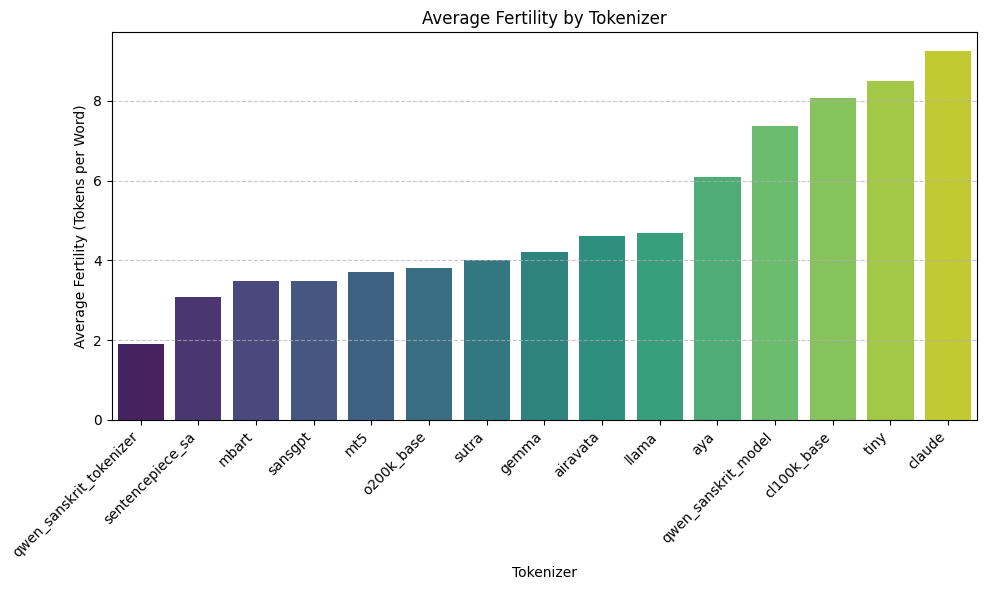

In [257]:
import matplotlib.pyplot as plt
import seaborn as sns

# Calculate average fertility per tokenizer
fertility_summary = (
    df.groupby('tokenizer')['fertility']
      .mean()
      .reset_index()
      .sort_values('fertility', ascending=True)
)

plt.figure(figsize=(10, 6))
sns.barplot(
    x='tokenizer',
    y='fertility',
    data=fertility_summary,
    palette='viridis'
)

plt.title('Average Fertility by Tokenizer')
plt.xlabel('Tokenizer')
plt.ylabel('Average Fertility (Tokens per Word)')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()